# Phase Scintillation Analysis — Windowed PSD Method

This notebook converts Doppler residuals into phase fluctuations and computes band-limited phase scintillation using a spectral (PSD-based) method.

---

## Method

The processing steps are:

1. Load filtered Doppler data
2. Convert Doppler frequency → phase:
   
   φ(t) = 2π ∫ f(t) dt

3. Segment data into overlapping time windows:
   - window length: 20 minutes
   - step size: 10 minutes

4. For each window:
   - compute power spectral density (Welch method)
   - integrate PSD over the scintillation band:
     
     3×10⁻⁴ Hz to 3×10⁻² Hz

5. Compute band-limited phase RMS for each window

---

## Output

This notebook produces:

- `phase_windows_<year>.csv`

Each row represents a time window with:

- phase RMS (rad)
- number of samples
- window timing

This dataset is the core input for CIR and CME detection.

In [8]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
from config.settings_2014 import *

deBug= True
sav_file = True

from src.io_utils import load_dsn_data
from src.phase_utils import compute_phase_rms_windows, print_phase_summary
from src.io_utils import load_horizons_daily_sep
from src.plot_utils import plot_phase_scintillation_time_series

In [10]:
df = load_dsn_data(
    DOPPLER_FILE,
    valid_only=USE_VALID_FLAG,
    min_elev_deg=MIN_ELEV_DEG,
    max_abs_doppler_hz=MAX_ABS_DOPPLER_HZ,
)


if deBug == True:
    print("DSN rows after filtering:", len(df))
    print("DSN time range:", df["UTC_time"].min(), "→", df["UTC_time"].max())
    
    df.head()

DSN rows after filtering: 264517
DSN time range: 2014-01-01 10:07:53.112000 → 2014-06-04 17:05:39.955000


In [11]:
windows_df = compute_phase_rms_windows(
    df,
    time_col="UTC_time",
    doppler_col="doppler",
    dt_target_sec=DT_TARGET,
    window_min=WINDOW_MIN,
    step_min=STEP_MIN,
    min_samples=MIN_SAMPLES,
    f_low_hz=F_LOW,
    f_high_hz=F_HIGH,
)
if deBug ==True:
    print_phase_summary(windows_df)
    
    windows_df.head()
    print(windows_df.columns.tolist())
    windows_df.tail()




horizons_daily = load_horizons_daily_sep(HORIZONS_FILE)

# convert to datetime index
geom = horizons_daily.set_index("day")

# reindex to window mid-times using nearest or interpolation
windows_df["elongation_deg"] = np.interp(
    windows_df["mid"].astype("int64"),
    geom.index.astype("int64"),
    geom["elongation_deg"]
)

Windows created: 4512
Window time range: 2014-01-01 10:07:50 → 2014-06-04 16:57:50
Phase RMS range (rad): 0.06483397709976174 → 22.227667474200462
['start', 'end', 'mid', 'phase_rms_rad', 'n_samples']


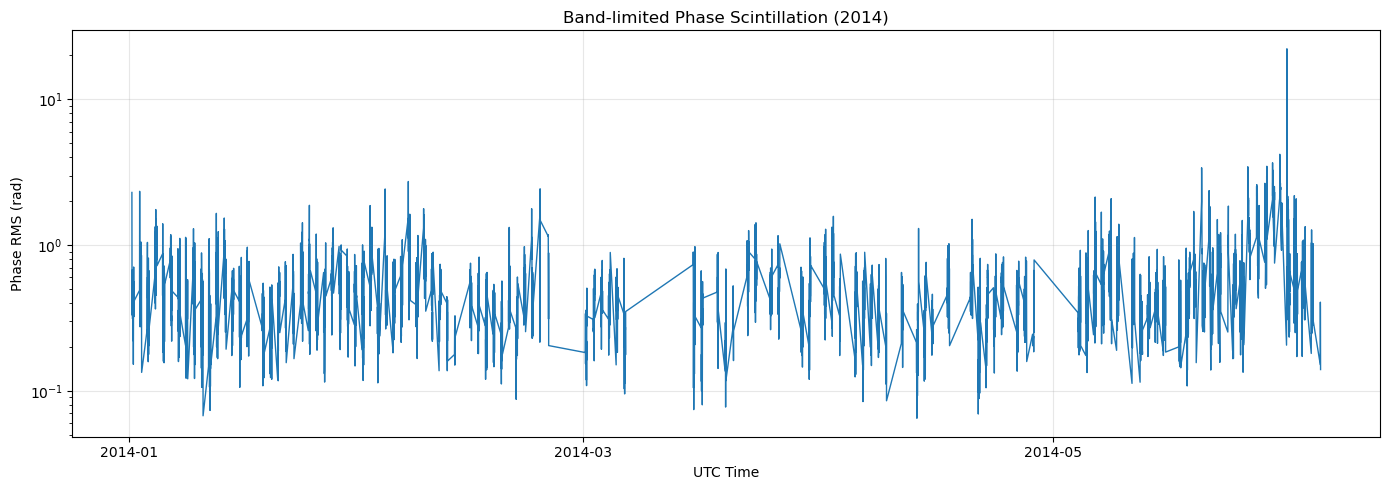

In [12]:
fig, ax = plot_phase_scintillation_time_series(windows_df, year=YEAR)
plt.show()

In [13]:
if sav_file == True:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    phase_csv = OUTPUT_DIR / f"phase_windows_{YEAR}.csv"
    fig_path = OUTPUT_DIR / f"phase_scintillation_{YEAR}.png"
    
    windows_df.to_csv(phase_csv, index=False)
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    
    print("Saved:", phase_csv)
    print("Saved:", fig_path)
    print("Saved CSV exists:", phase_csv.exists(), phase_csv)
    print("Saved figure exists:", fig_path.exists(), fig_path)

Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/phase_windows_2014.csv
Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/phase_scintillation_2014.png
Saved CSV exists: True /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/phase_windows_2014.csv
Saved figure exists: True /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/phase_scintillation_2014.png


In [14]:
if deBug == True:
    valid = windows_df["phase_rms_rad"].dropna()

    print("Number of windows:", len(windows_df))
    print("Phase RMS min:", valid.min())
    print("Phase RMS median:", valid.median())
    print("Phase RMS max:", valid.max())
    print("Median samples per window:", windows_df["n_samples"].median())

Number of windows: 4512
Phase RMS min: 0.06483397709976174
Phase RMS median: 0.43755859821454235
Phase RMS max: 22.227667474200462
Median samples per window: 120.0
